In [37]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon


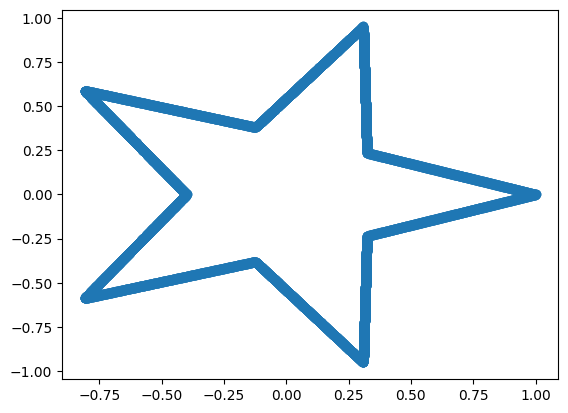

In [38]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [39]:
class Config:
    def __init__(self):
        self.data_samples = 5000
        self.batch_size   = 256
        self.lr           = 1e-3
        self.epochs       = 500
        self.hidden_dim   = 128
        self.num_timesteps = 100
        self.beta_min     = 0.1
        self.beta_max     = 20.0


In [40]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)


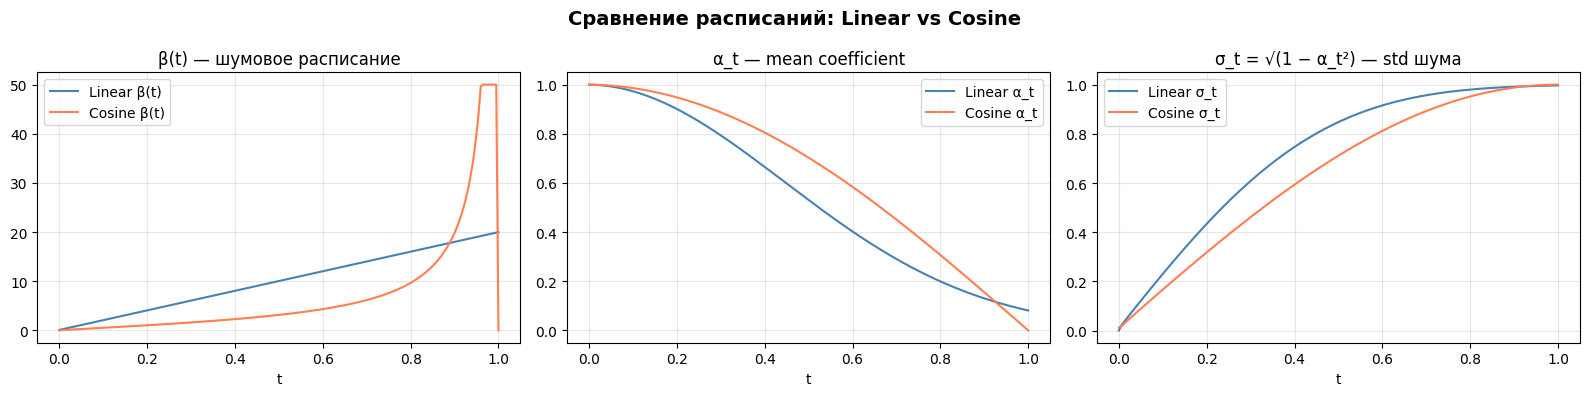

In [41]:
def weight_constant(t, config, beta_func):
    return torch.ones_like(t)

def weight_linear(t, config, beta_func):
    return t + 0.1

def weight_exp(t, config, beta_func):
    return torch.exp(2 * t)

def beta_linear(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def beta_cosine_from_alpha(t):
    s = 0.008
    theta = (t + s) / (1 + s) * math.pi / 2
    alpha = torch.cos(theta) ** 2
    dtheta_dt = math.pi / (2 * (1 + s))
    dalpha_dt = -2 * torch.cos(theta) * torch.sin(theta) * dtheta_dt
    beta = -dalpha_dt / (alpha + 1e-8)
    return torch.clamp(beta, min=1e-5, max=50.0)

def marginal_alpha(t, config, schedule):
    if schedule == 'linear':
        log_alpha = -0.25 * (config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2)
        return torch.exp(log_alpha)
    else:
        s = 0.008
        alpha_t = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        alpha_0 = math.cos(s / (1 + s) * math.pi / 2) ** 2
        return torch.clamp(torch.sqrt(alpha_t / alpha_0), max=0.9999)

config = Config()
t_vis = torch.linspace(0, 1, 200)

alpha_lin = marginal_alpha(t_vis, config, 'linear').numpy()
alpha_cos = marginal_alpha(t_vis, config, 'cosine').numpy()
beta_lin  = beta_linear(t_vis, config).numpy()
beta_cos  = beta_cosine_from_alpha(t_vis).numpy()
sigma_lin = np.sqrt(np.clip(1 - alpha_lin**2, 1e-6, None))
sigma_cos = np.sqrt(np.clip(1 - alpha_cos**2, 1e-6, None))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Сравнение расписаний: Linear vs Cosine', fontsize=14, fontweight='bold')

axes[0].plot(t_vis, beta_lin, label='Linear β(t)', color='steelblue')
axes[0].plot(t_vis, beta_cos, label='Cosine β(t)', color='coral')
axes[0].set_title('β(t) — шумовое расписание')
axes[0].set_xlabel('t'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_vis, alpha_lin, label='Linear α_t', color='steelblue')
axes[1].plot(t_vis, alpha_cos, label='Cosine α_t', color='coral')
axes[1].set_title('α_t — mean coefficient')
axes[1].set_xlabel('t'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_vis, sigma_lin, label='Linear σ_t', color='steelblue')
axes[2].plot(t_vis, sigma_cos, label='Cosine σ_t', color='coral')
axes[2].set_title('σ_t = √(1 − α_t²) — std шума')
axes[2].set_xlabel('t'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [42]:
class VPTrainer:
    def __init__(self, config, schedule, weight_func, name, data):
        self.config      = config
        self.schedule    = schedule
        self.weight_func = weight_func
        self.name        = name
        self.device      = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        self.data    = torch.tensor(data, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.loader  = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model     = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.loss_history = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.loader:
            batch = batch.to(self.device)
            t = torch.rand(batch.shape[0], 1, device=self.device)

            alpha_t = marginal_alpha(t, self.config, self.schedule)
            sigma_t = torch.sqrt(torch.clamp(1.0 - alpha_t**2, min=1e-8))

            eps   = torch.randn_like(batch)
            x_t   = alpha_t * batch + sigma_t * eps

            eps_pred = self.model(x_t, t)

            w    = self.weight_func(t, self.config, self.schedule)
            loss = (w * (eps_pred - eps)**2).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        print(f'Training {self.name}...')
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            self.loss_history.append(loss)
            if epoch % 100 == 0:
                print(f'  Epoch {epoch:>4d}  Loss: {loss:.4f}')
        print(f'  Done. Final loss: {self.loss_history[-1]:.4f}')


In [43]:
@torch.no_grad()
def sample_vp_sde(model, config, schedule, num_samples=5000):
    device = next(model.parameters()).device
    model.eval()

    x  = torch.randn(num_samples, 2, device=device)
    dt = 1.0 / config.num_timesteps
    t_min = 1e-3

    for i in range(config.num_timesteps):
        t_val    = max(1.0 - i * dt, t_min)
        t_tensor = torch.full((num_samples, 1), t_val, device=device)

        if schedule == 'linear':
            beta_t = beta_linear(t_tensor, config)
        else:
            beta_t = beta_cosine_from_alpha(t_tensor)

        alpha_t = marginal_alpha(t_tensor, config, schedule)
        sigma_t = torch.sqrt(torch.clamp(1.0 - alpha_t**2, min=1e-6))
        eps_pred = model(x, t_tensor)
        score    = -eps_pred / sigma_t

        drift     = (-0.5 * beta_t * x - beta_t * score) * dt
        diffusion = torch.sqrt(beta_t * dt) * torch.randn_like(x)
        x = x - drift + diffusion

    return x.cpu().numpy()


In [44]:
def calculate_metrics(samples, real_samples, bins=50):
    rng = [[-1.5, 1.5], [-1.5, 1.5]]
    h_s, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, range=rng)
    h_r, _, _ = np.histogram2d(real_samples[:, 0], real_samples[:, 1], bins=bins, range=rng)

    h_s = h_s / (h_s.sum() + 1e-8)
    h_r = h_r / (h_r.sum() + 1e-8)

    eps = 1e-10
    js_div  = jensenshannon(h_s.flatten(), h_r.flatten()) ** 2
    ent_s   = entropy((h_s + eps).flatten())
    ent_r   = entropy((h_r + eps).flatten())
    coverage = (h_s > 0).sum() / max((h_r > 0).sum(), 1)

    return {
        'JS_divergence': float(js_div),
        'entropy_samples': float(ent_s),
        'entropy_real': float(ent_r),
        'coverage': float(coverage),
    }


Training Linear_Constant...
  Epoch    0  Loss: 0.8169
  Epoch  100  Loss: 0.2417
  Epoch  200  Loss: 0.2179
  Epoch  300  Loss: 0.2285
  Epoch  400  Loss: 0.2128
  Done. Final loss: 0.2171


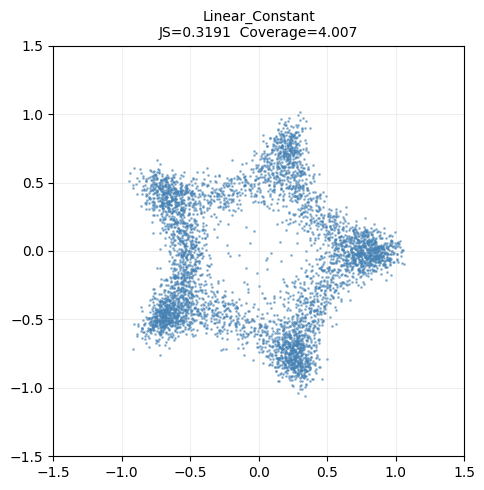

Training Linear_Linear_w...
  Epoch    0  Loss: 0.4797
  Epoch  100  Loss: 0.0731
  Epoch  200  Loss: 0.0714
  Epoch  300  Loss: 0.0643
  Epoch  400  Loss: 0.0662
  Done. Final loss: 0.0658


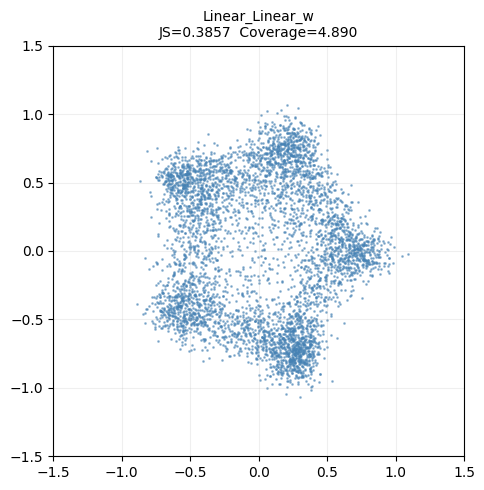

Training Linear_Exp_w...
  Epoch    0  Loss: 2.6747
  Epoch  100  Loss: 0.3885
  Epoch  200  Loss: 0.3659
  Epoch  300  Loss: 0.3625
  Epoch  400  Loss: 0.3524
  Done. Final loss: 0.3662


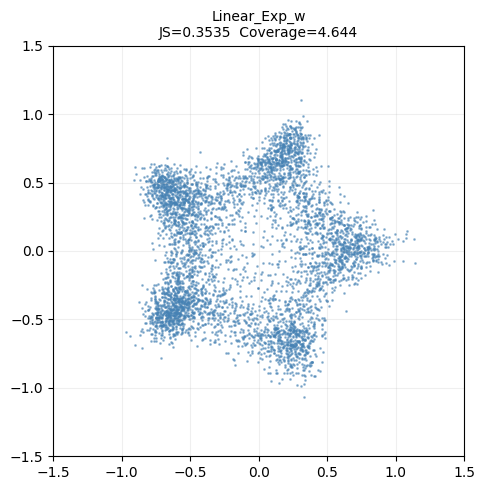

Training Cosine_Constant...
  Epoch    0  Loss: 0.8397
  Epoch  100  Loss: 0.3019
  Epoch  200  Loss: 0.3004
  Epoch  300  Loss: 0.3018
  Epoch  400  Loss: 0.2841
  Done. Final loss: 0.2901


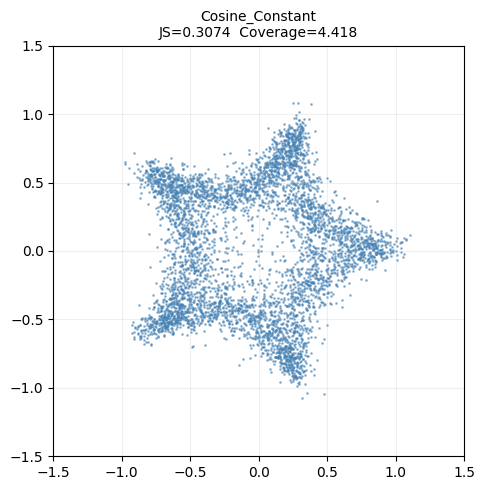

Training Cosine_Linear_w...
  Epoch    0  Loss: 0.4936
  Epoch  100  Loss: 0.1041
  Epoch  200  Loss: 0.1019
  Epoch  300  Loss: 0.0983
  Epoch  400  Loss: 0.0954
  Done. Final loss: 0.1026


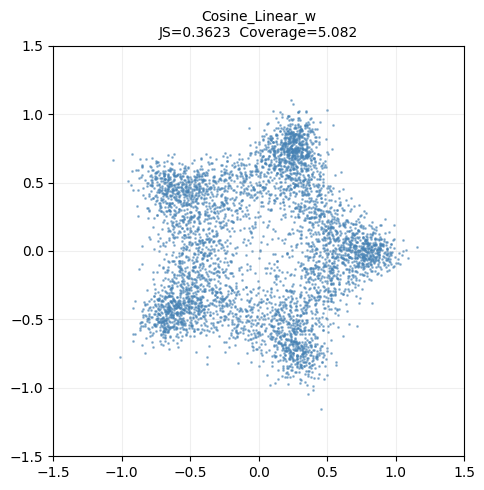

Training Cosine_Exp_w...
  Epoch    0  Loss: 2.5552
  Epoch  100  Loss: 0.5582
  Epoch  200  Loss: 0.5192
  Epoch  300  Loss: 0.5196
  Epoch  400  Loss: 0.5071
  Done. Final loss: 0.5069


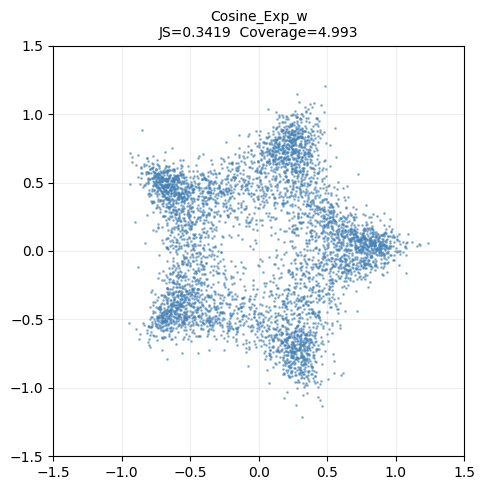

In [45]:
config    = Config()
real_star = generate_star(n_samples=5000)

schedules = {
    'Linear' : 'linear',
    'Cosine' : 'cosine',
}

weight_functions = {
    'Constant' : weight_constant,
    'Linear_w' : weight_linear,
    'Exp_w'    : weight_exp,
}

all_results = {}

for sched_name, sched_key in schedules.items():
    for w_name, w_func in weight_functions.items():
        combo_name = f'{sched_name}_{w_name}'

        trainer = VPTrainer(config, sched_key, w_func, combo_name, real_star)
        trainer.run()

        samples = sample_vp_sde(trainer.model, config, sched_key, num_samples=5000)
        metrics = calculate_metrics(samples, real_star)

        all_results[combo_name] = {
            'samples'      : samples,
            'metrics'      : metrics,
            'loss_history' : trainer.loss_history,
            'schedule'     : sched_name,
            'weight'       : w_name,
        }

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5, c='steelblue')
        ax.set_title(
            f'{combo_name}\n'
            f'JS={metrics["JS_divergence"]:.4f}  Coverage={metrics["coverage"]:.3f}',
            fontsize=10
        )
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

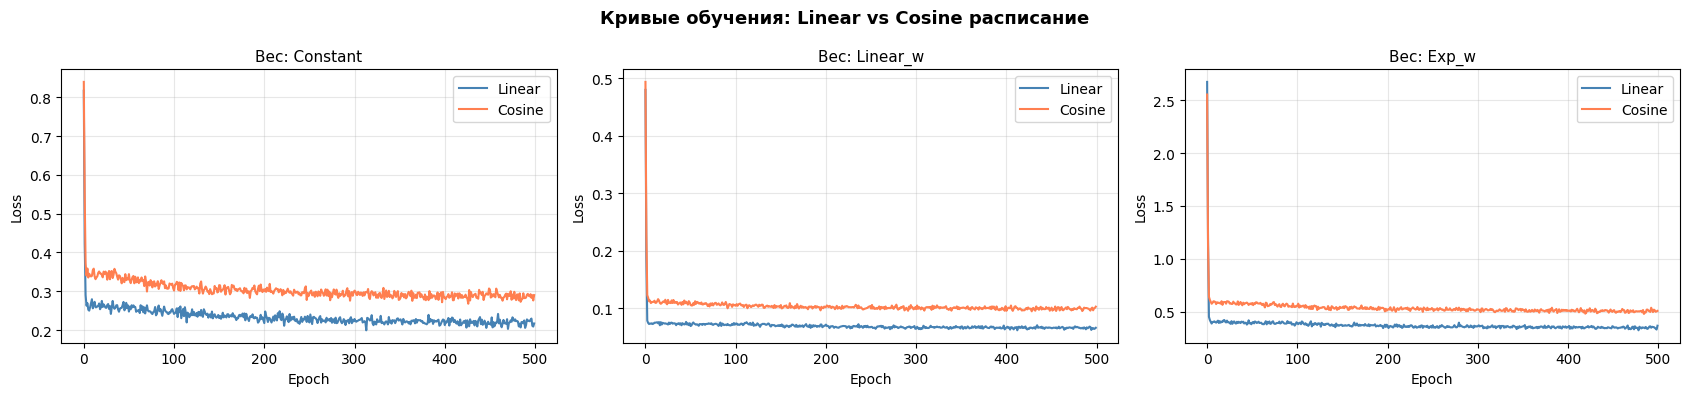

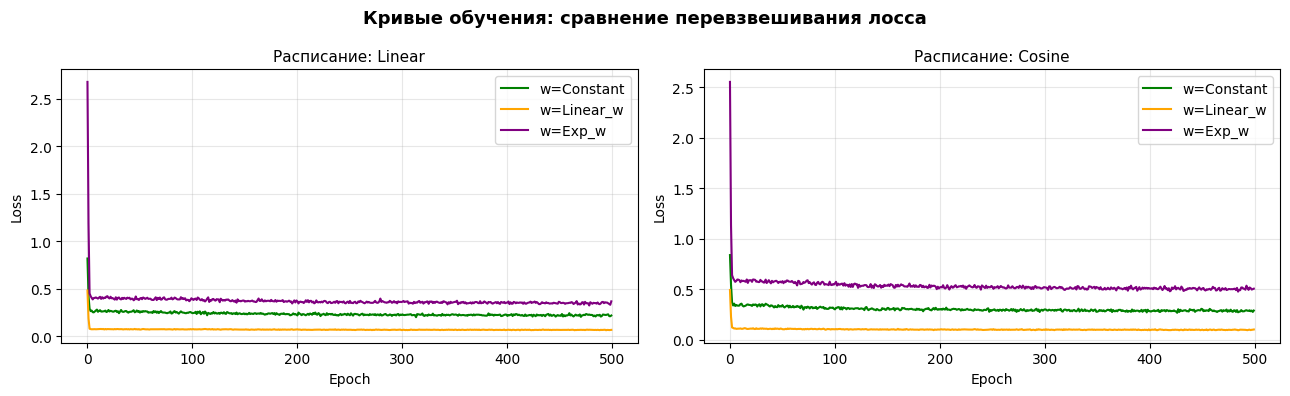

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
fig.suptitle('Кривые обучения: Linear vs Cosine расписание', fontsize=13, fontweight='bold')

colors = {'Linear': 'steelblue', 'Cosine': 'coral'}

for ax, w_name in zip(axes, weight_functions.keys()):
    for sched_name in schedules:
        combo = f'{sched_name}_{w_name}'
        hist  = all_results[combo]['loss_history']
        ax.plot(hist, label=sched_name, color=colors[sched_name], linewidth=1.5)
    ax.set_title(f'Вес: {w_name}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle('Кривые обучения: сравнение перевзвешивания лосса', fontsize=13, fontweight='bold')

w_colors = {'Constant': 'green', 'Linear_w': 'orange', 'Exp_w': 'purple'}

for ax, sched_name in zip(axes, schedules):
    for w_name in weight_functions:
        combo = f'{sched_name}_{w_name}'
        hist  = all_results[combo]['loss_history']
        ax.plot(hist, label=f'w={w_name}', color=w_colors[w_name], linewidth=1.5)
    ax.set_title(f'Расписание: {sched_name}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [47]:
print('=' * 75)
print('ИТОГОВЫЕ МЕТРИКИ — VP-SDE (все комбинации)')
print('=' * 75)
print(f'{"Комбинация":<28} {"JS ↓":<14} {"Coverage ↑":<14} {"EntropyRatio":<12}')
print('-' * 75)

for name, data in all_results.items():
    m  = data['metrics']
    er = m['entropy_samples'] / m['entropy_real']
    print(f'{name:<28} {m["JS_divergence"]:<14.4f} {m["coverage"]:<14.3f} {er:<12.3f}')


ИТОГОВЫЕ МЕТРИКИ — VP-SDE (все комбинации)
Комбинация                   JS ↓           Coverage ↑     EntropyRatio
---------------------------------------------------------------------------
Linear_Constant              0.3191         4.007          1.222       
Linear_Linear_w              0.3857         4.890          1.285       
Linear_Exp_w                 0.3535         4.644          1.264       
Cosine_Constant              0.3074         4.418          1.264       
Cosine_Linear_w              0.3623         5.082          1.292       
Cosine_Exp_w                 0.3419         4.993          1.283       


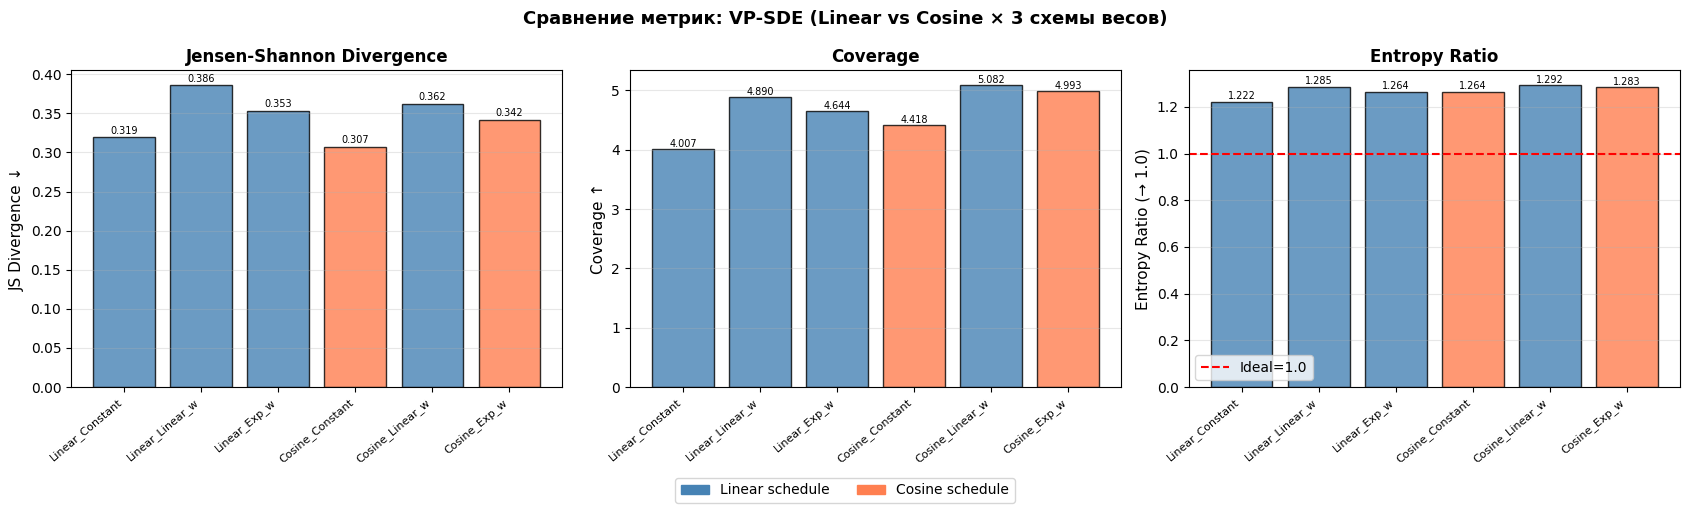

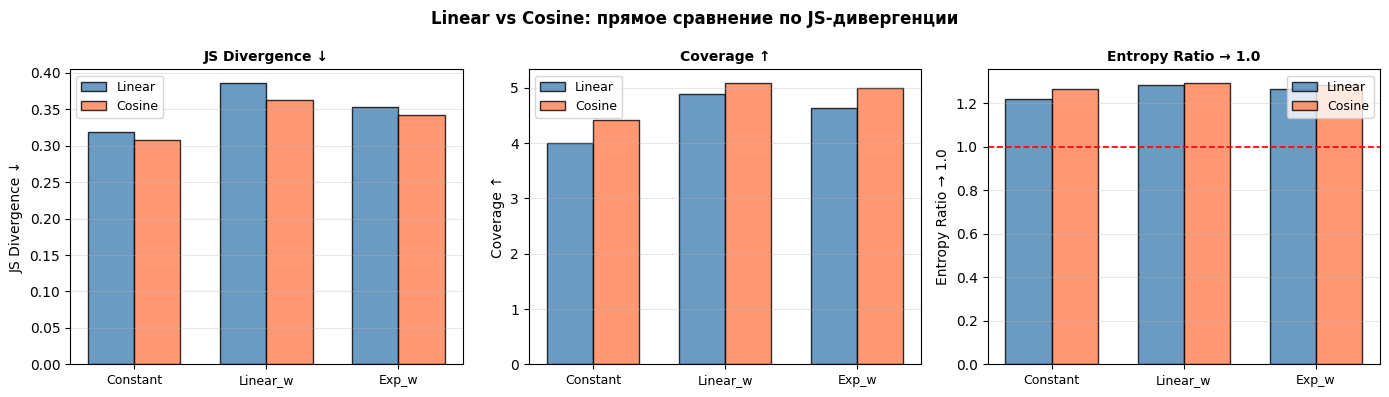

In [48]:
combinations = list(all_results.keys())
js_div    = [all_results[n]['metrics']['JS_divergence'] for n in combinations]
coverage  = [all_results[n]['metrics']['coverage']      for n in combinations]
ent_ratio = [
    all_results[n]['metrics']['entropy_samples'] / all_results[n]['metrics']['entropy_real']
    for n in combinations
]

bar_colors = ['steelblue' if 'Linear' in n else 'coral' for n in combinations]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Сравнение метрик: VP-SDE (Linear vs Cosine × 3 схемы весов)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='steelblue', label='Linear schedule'),
    Patch(color='coral',     label='Cosine schedule'),
]

for ax, vals, ylabel, title, better in zip(
    axes,
    [js_div, coverage, ent_ratio],
    ['JS Divergence ↓', 'Coverage ↑', 'Entropy Ratio (→ 1.0)'],
    ['Jensen-Shannon Divergence', 'Coverage', 'Entropy Ratio'],
    ['min', 'max', 'one'],
):
    bars = ax.bar(range(len(combinations)), vals, color=bar_colors, alpha=0.8, edgecolor='k')
    if better == 'one':
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Ideal=1.0')
        ax.legend()
    ax.set_xticks(range(len(combinations)))
    ax.set_xticklabels(combinations, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Linear vs Cosine: прямое сравнение по JS-дивергенции', fontsize=12, fontweight='bold')

w_names = list(weight_functions.keys())
x = np.arange(len(w_names))
width = 0.35

for ax, metric_key, label in zip(
    axes,
    ['JS_divergence', 'coverage', None],
    ['JS Divergence ↓', 'Coverage ↑', 'Entropy Ratio → 1.0']
):
    lin_vals, cos_vals = [], []
    for w in w_names:
        if metric_key is not None:
            lin_vals.append(all_results[f'Linear_{w}']['metrics'][metric_key])
            cos_vals.append(all_results[f'Cosine_{w}']['metrics'][metric_key])
        else:
            lin_vals.append(
                all_results[f'Linear_{w}']['metrics']['entropy_samples'] /
                all_results[f'Linear_{w}']['metrics']['entropy_real']
            )
            cos_vals.append(
                all_results[f'Cosine_{w}']['metrics']['entropy_samples'] /
                all_results[f'Cosine_{w}']['metrics']['entropy_real']
            )
    ax.bar(x - width/2, lin_vals, width, label='Linear', color='steelblue', alpha=0.8, edgecolor='k')
    ax.bar(x + width/2, cos_vals, width, label='Cosine',  color='coral',     alpha=0.8, edgecolor='k')
    if metric_key is None:
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(w_names, fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Выводы

Косинусное расписание с константным весом лосса (Cosine_Constant) оказалось лучшим, потому что косинус медленнее разрушает данные и модель лучше учится восстанавливать форму звезды. Экспоненциальный вес лосса — плохая идея, модель забивает на детали и думает только про сильно зашумлённые примеры.
